In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import doralite
import gfdl_utils.core as gu

import numpy as np
import xarray as xr
import CM4Xutils

import cmocean
import matplotlib.pyplot as plt

In [10]:
# no edits: odiv-331
# first pass edits: odiv-323
# v3 edits (w/ deep): odiv-339

In [11]:
odiv_projects = doralite.list_project("odiv")['project']
OM5_experiments = [e for e in odiv_projects if e['title'] == "OM5 experiments"][0]['experiments'];

In [12]:
{e['expName']:e['id'] for e in OM5_experiments};

In [13]:
gebco = xr.open_dataset("/archive/gold/datasets/topography/GEBCO_2023/GEBCO_2023.nc").sel(lon=slice(-41, -37), lat=slice(-33, -27)).compute()

In [14]:
def load(exp, ppname="ocean_annual"):
    pp = doralite.dora_metadata(exp)['pathPP']
    ppname = "ocean_annual"
    
    grid = gu.open_static(pp, ppname)
    if exp=="odiv-255":
        sgpath = (
                    "/archive/Raphael.Dussin/datasets/OM4p125"
                    "/mosaic_c192_om4p125_bedmachine_v20210310_hydrographyKDunne20210614_unpacked/"
                    "ocean_hgrid.nc"
                )
        sg  = xr.open_dataset(sgpath)
        grid = CM4Xutils.fix_geo_coords(grid, sg)
    
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(
        pp,
        ppname,
        out,
        local,
        "*",
        ["thetao","thkcello"],
        dmget=True
    )
    
    ds = ds.assign_coords({
        "xh"       : xr.DataArray(grid.xh.values,        dims=("xh",      )),
        "yh"       : xr.DataArray(grid.yh.values,        dims=("yh",      )),
        "areacello": xr.DataArray(grid.areacello.values, dims=("yh", "xh",)),
        "deptho"   : xr.DataArray(grid.deptho.values,    dims=("yh", "xh",)),
        "geolon"   : xr.DataArray(grid.geolon.values,    dims=("yh", "xh",)),
        "geolat"   : xr.DataArray(grid.geolat.values,    dims=("yh", "xh",))
    })
    
    return ds, grid

In [15]:
d = {}
for exp in ["odiv-331", "odiv-255", "odiv-339"]:
    ds, grid = load(exp)
    d[exp] = (ds, grid)

Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.


In [16]:
cmap = cmocean.cm.deep
pckw = {"cmap":cmap, "vmin":3600, "vmax":5100}
ctkw = {"levels":[4550], "colors":"C1", "linewidths":1.25, "alpha":0.75}

x0, y0 = -39, -30
xlim = [x0-2, x0+2]
ylim = [y0-3, y0+3]

def plot_vema(exp):
    ds, grid = d[exp]
    
    plt.pcolormesh(
        grid['geolon_c'].where(grid.geolon_c <= 360., 360.),
        grid['geolat_c'].where(grid.geolat_c <= 90., 89.75),
        grid['deptho'],
        **pckw
    )
    
    cold_thk = (
        ds.thkcello.sel(time=slice("1990", "2000")).mean('time').where(
            ds.thetao.sel(time=slice("1990", "2000")).mean('time') <= 0.25
        ).sum("zl")
    ).compute()
    
    # plt.pcolormesh(
    #     grid['geolon_c'].where(grid.geolon_c <= 360., 360.),
    #     grid['geolat_c'].where(grid.geolat_c <= 90., 89.75),
    #     cold_thk.where(cold_thk>1.),
    #     cmap="Reds", alpha=0.5,
    #     vmin=0, vmax=1000
    # )
    
    plt.contour(
        grid['geolon'],
        grid['geolat'],
        grid['deptho'],
        **ctkw
    )
    
    plt.xlim(xlim)
    plt.ylim(ylim)

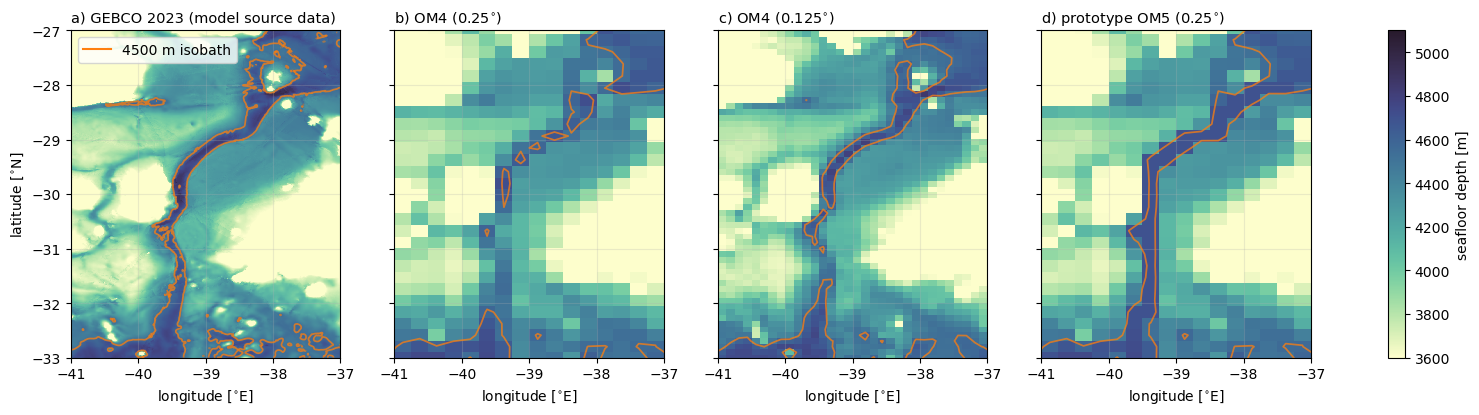

In [17]:
fig, axes = plt.subplots(1,4,figsize=(20,4.25))

plt.sca(axes[0])
pc = (-gebco['elevation']).plot(**pckw, add_colorbar=False)
(-gebco['elevation']).plot.contour(**ctkw)
plt.plot([], [], color=ctkw["colors"], label="4500 m isobath")
plt.legend(loc="upper left")
plt.xlabel(r"longitude [$^{\circ}$E]")
plt.ylabel(r"latitude [$^{\circ}$N]")
plt.title("a) GEBCO 2023 (model source data)", loc="left", fontsize=10.5)
plt.grid(True, alpha=0.25)

plt.sca(axes[1])
plot_vema("odiv-331")
plt.xlabel(r"longitude [$^{\circ}$E]")
plt.ylabel("")
plt.yticks(axes[0].get_yticks(), labels=[""]*len(axes[0].get_yticks()))
plt.title(r"b) OM4 (0.25$^{\circ}$)", loc="left", fontsize=10.5)
plt.grid(True, alpha=0.25)

plt.sca(axes[2])
plot_vema("odiv-255")
plt.xlabel(r"longitude [$^{\circ}$E]")
plt.ylabel("")
plt.yticks(axes[0].get_yticks(), labels=[""]*len(axes[0].get_yticks()))
plt.title("c) OM4 (0.125$^{\circ}$)", loc="left", fontsize=10.5)
plt.grid(True, alpha=0.25)

plt.sca(axes[3])
plot_vema("odiv-339")
plt.xlabel(r"longitude [$^{\circ}$E]")
plt.ylabel("")
plt.yticks(axes[0].get_yticks(), labels=[""]*len(axes[0].get_yticks()))
plt.title("d) prototype OM5 (0.25$^{\circ}$)", loc="left", fontsize=10.5)
plt.grid(True, alpha=0.25)


fig.colorbar(pc, ax=axes[:], label="seafloor depth [m]");
plt.savefig("/work/hfd/projects/DeepChannels/figures/VemaChannelResolution.png", bbox_inches="tight", dpi=300)

In [179]:
vema = d['odiv-331'][0].sel(xh=slice(-42, -25), yh=slice(-33, -22))

In [180]:
cold_thk = vema.thkcello.mean('time').where(vema.thetao.mean('time') < 0.05).sum("zl").compute()

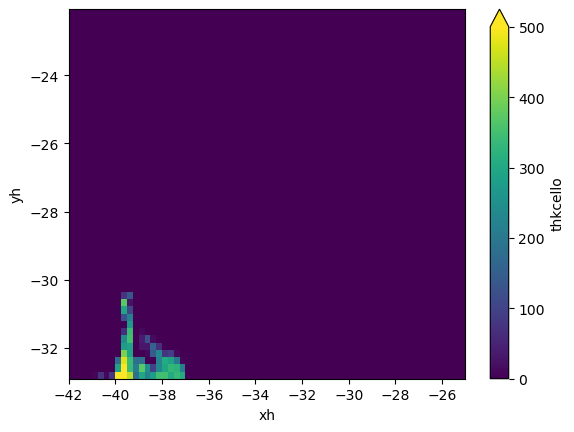

In [181]:
cold_thk.plot(vmin=0, vmax=500)

In [185]:
vema = d['odiv-255'][0].sel(xh=slice(-42, -25), yh=slice(-33, -22))

In [186]:
cold_thk = vema.thkcello.mean('time').where(vema.thetao.mean('time') < 0.05).sum("zl").compute()

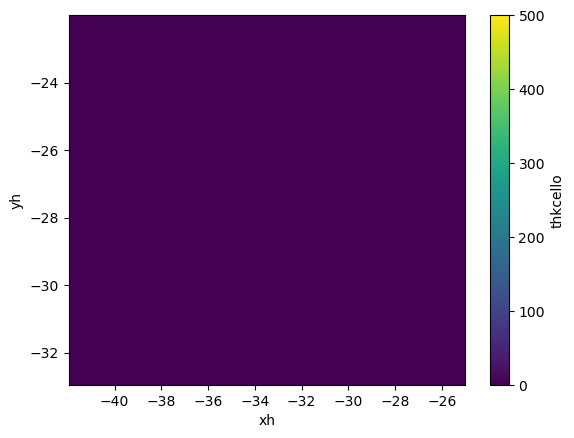

In [187]:
cold_thk.plot(vmin=0, vmax=500) 

In [182]:
vema = d['odiv-339'][0].sel(xh=slice(-42, -25), yh=slice(-33, -22))

In [183]:
cold_thk = vema.thkcello.mean('time').where(vema.thetao.mean('time') < 0.05).sum("zl").compute()

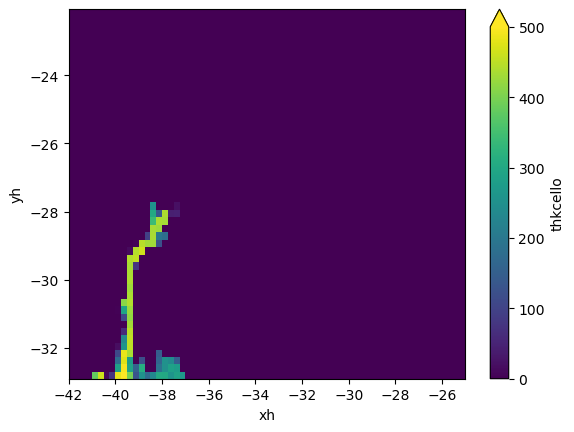

In [184]:
cold_thk.plot(vmin=0, vmax=500)